# STOPP


In [2]:
from cellpose.io import imread
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
from skimage.measure import label, regionprops


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


In [14]:
# path = r"E:\HT1080\c3_6well_5min_10x\_4\Pos10"  
path = r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos2"

image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
img = imread(image_list[0])



In [15]:
first_frame = 50
last_frame = 150
df_list = Parallel(n_jobs=5)(delayed(lambda img: analyze_defects(img, sigma=21)[1:])(imread(img)) for img in image_list[first_frame:last_frame-1])
for i, df in enumerate(df_list):
    df[0]['frame'] = i
    df[1]['frame'] = i

# Concatenate the DataFrames
df_plus = pd.concat([df[0] for df in df_list], ignore_index=True)
df_minus = pd.concat([df[1] for df in df_list], ignore_index=True)

<AxesSubplot: xlabel='frame'>

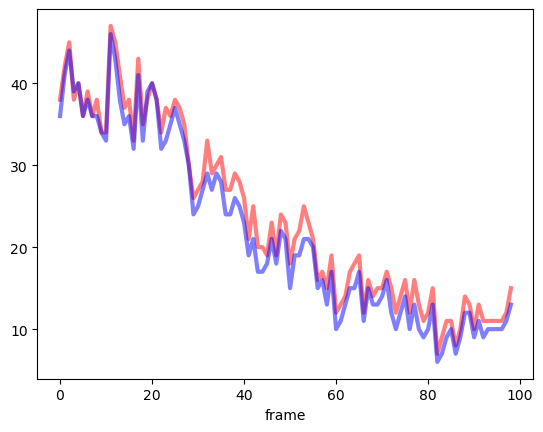

In [16]:
df_plus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="r")
df_minus.groupby('frame').size().plot(linewidth=3, alpha=.5, color="b")

In [22]:
first_frame = 50
last_frame = 150
box = 210

# NOTICE MINUS analyze_defects(img1, sigma=ori_sigma)[2] is calculated now!

ori_sigma = 21
flow_sigma = 15


u_v_count = Parallel(n_jobs=5)(delayed(defect_flow_frame_average_with_edge)(
    imread(img1), imread(img2), 
    analyze_defects(imread(img1), sigma=ori_sigma)[2][['x','y','ang1']].rename(columns={"x":"xp", "y":"yp", "ang1":"angp1"}),
    defect_type="all", 
    box=(int(box),int(box)),
    sigma=flow_sigma,
    ) for img1,img2 in zip(image_list[first_frame:last_frame-1], image_list[first_frame+1:last_frame]))

In [204]:
u_v_count[0]

(array([[ 0.47129056,  0.6165599 ,  0.6071085 , ..., -0.5284576 ,
         -0.5505743 , -0.55549496],
        [ 0.5672683 ,  0.5785951 ,  0.5570095 , ..., -0.51236415,
         -0.54664046, -0.5590686 ],
        [ 0.5476511 ,  0.5535707 ,  0.53632677, ..., -0.5072919 ,
         -0.55455476, -0.5752083 ],
        ...,
        [ 0.19230913,  0.1530345 ,  0.1478789 , ...,  0.53713924,
          0.51929325,  0.52425474],
        [ 0.22484858,  0.20486684,  0.18989863, ...,  0.57235533,
          0.5453028 ,  0.53964967],
        [ 0.26166648,  0.25378233,  0.23054609, ...,  0.60467553,
          0.5735764 ,  0.5614079 ]], dtype=float32),
 array([[-0.22575565, -0.36509785, -0.39175922, ...,  0.39600623,
          0.36008513,  0.33125174],
        [-0.2547109 , -0.26930362, -0.28206566, ...,  0.34464884,
          0.30199403,  0.26761085],
        [-0.21310279, -0.2145319 , -0.21850787, ...,  0.3071328 ,
          0.26223177,  0.22584862],
        ...,
        [-0.14382678, -0.09750407, -0.0

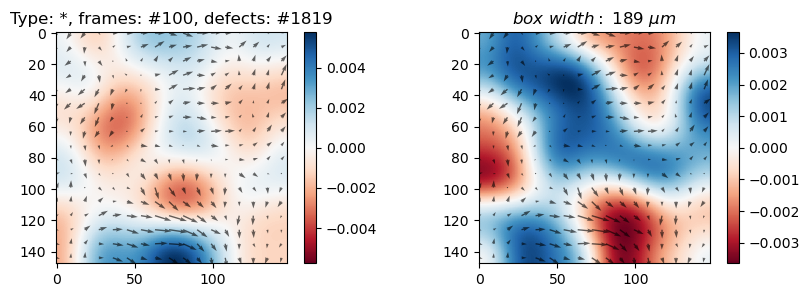

In [23]:
%matplotlib inline
u, v, count = [], [], []
for q in u_v_count:
    if q:
        u.append(q[0])
        v.append(q[1])
        count.append(q[2])
u = np.array(u)
v = np.array(v)
count = np.array(count)  

n, m = 0,-1 #800,900 #600,800 #450,550 #150,250 #50,150
u_up = np.average(u[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])
v_up = np.average(v[count!= 0][n:m,:,:], axis=0, weights=count[count!= 0][n:m])

filt = 15
step = 9
vscale = 3
vort_mag, div_mag = .02, .01

fig, axs = plt.subplots(1,2, figsize=(10,3))
# for ax in axs.ravel(): ax.axis('off')
ax1, ax2 = axs.ravel()

field = np.stack((u_up, v_up), axis=-1)
y, x = np.mgrid[0:u_up.shape[0], 0:u_up.shape[1]] 
vorticity = gaussian_filter(curl_npgrad(field), sigma=filt)
c1 = ax1.imshow(vorticity, cmap='RdBu', vmin=-vorticity.max(), vmax=vorticity.max())
ax1.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax1.set_title("Type: %1s, frames: #%1d, defects: #%1d" % ("*", last_frame-first_frame, np.sum(count)))
fig.colorbar(c1)

divergence = gaussian_filter(divergence_npgrad(field), sigma=filt)
c2 = ax2.imshow(divergence, cmap='RdBu', vmin=-divergence.max(), vmax=divergence.max())
ax2.quiver(x[::step, ::step], y[::step, ::step], 
          u_up[::step, ::step], -v_up[::step, ::step],  color='k',
          width=.006, scale=vscale, alpha=.6)
ax2.set_title("$box ~width: ~%1d ~\mu m$" % (box * .9))
fig.colorbar(c2)

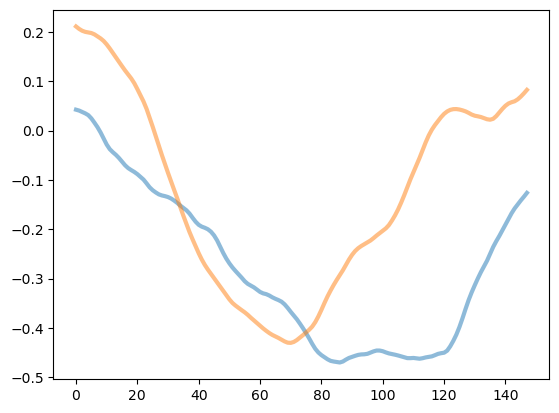

In [10]:
midlle = u_up.shape[1]//2
plt.plot(u_up[midlle-10:midlle+10,:].mean(axis=0), linewidth=3, alpha=.5)
plt.plot(u_up[:,midlle-10:midlle+10].mean(axis=1), linewidth=3, alpha=.5)

In [212]:
u_up.max()*1.8*4, u_up.min()

(2.7106034421389427, -0.039223903227850604)

# Mean Flow

In [16]:
%matplotlib qt
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))


# ax1.imshow(np.zeros_like(img, dtype=np.float32), cmap="gray")
# "E:\C2C12 and RPE in 6 well\15min5x\_1\Pos18"
image_list = glob.glob(r"E:\HT1080\c3_6well_5min_10x\_2\Pos10\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())

img = imread(image_list[55])
img_clahe = clahe.apply(img)
ori, plusR, minR =  analyze_defects(img_clahe, sigma=21)

fig, ax1 = plt.subplots()
ax1.axis('off')
ax1.imshow(255-img_clahe, cmap="gray")  

s = 25
y, x = np.mgrid[0:img.shape[0], 0:img.shape[1]]
ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], np.arctan2(np.sin(ori), np.cos(ori))[::s,::s],
    headaxislength=0, headwidth=0, headlength=0, width=.005,
    scale=35, pivot='mid', alpha=0.5, cmap='hsv')


alpha_half, scale_half = .8, 20    
ax1.plot(plusR['x'], plusR['y'],'ro',markersize=8, alpha=alpha_half)
ax1.quiver(plusR['x'], plusR['y'], 
    np.cos(plusR['ang1']), -np.sin(plusR['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

ax1.plot(minR['x'], minR['y'],'wo',markersize=6, alpha=alpha_half)
for j in range(3):
    ax1.quiver(minR['x'], minR['y'], 
        np.cos(minR['ang'+str(j+1)]), -np.sin(minR['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='w', scale=scale_half, alpha=alpha_half)



plt.gca().set_box_aspect(1)


In [17]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))

fov_lst = [1,2,7,8, 13,14,20,21, 25,26,33,34]
image_list = glob.glob(r"E:\HT1080\c3_6well_5min_10x\_2\Pos"+str(fov_lst[1])+"\*.tif")
# image_list = glob.glob(r"E:\C2C12 and RPE in 6 well\15min5x\_1\Pos23\*.tif")
image_list = natsorted(image_list, key=lambda y: y.lower())


fig, axs = plt.subplots(1,2)
img_path = image_list[-1]
for ax,img_path in zip(axs, [image_list[4], image_list[-1]]):
    img = imread(img_path)
    img_clahe = clahe.apply(img)

    ax.imshow(255-img_clahe, cmap="gray")  
ax.set_title(os.path.basename(img_path))

Text(0.5, 1.0, 'img_channel000_position002_time000000436_z000.tif')

In [14]:

image_list = glob.glob(folder+"/Pos*/*.tif")
natsorted(image_list, key=lambda y: y.lower())[-1]

'E:\\HT1080\\c3_6well_5min_10x\\_4\\Pos36\\img_channel000_position036_time000000287_z000.tif'

In [40]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

def get_vrms(u,v):
    u = u-u.mean()
    v = v-v.mean()
    return ((u**2 + v**2)**.5).mean()

PLOT = False
folder = r"E:\HT1080\c3_6well_5min_10x\_5"
frame_num = -2
# fov_lst = [6,7,8,10, 13,14,20,21, 25,26,33,34]
fov_lst = np.arange(1,36)
df = pd.DataFrame()

colors = ["r","r","r","r",  "g","g","g","g", "b","b","b","b"]
for i,fov in enumerate(fov_lst):
    image_list = glob.glob(folder+"/Pos"+str(fov)+"\*.tif")
    image_list = natsorted(image_list, key=lambda y: y.lower())

    
    uv_vel_list = Parallel(n_jobs=5)(delayed(u_vel)(cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]))
    vrms = [get_vrms(uv[0],uv[1]) for uv in uv_vel_list]
    std = [(uv[0]-uv[0].mean()).std() for uv in uv_vel_list]
    time = np.arange(len(vrms))

    if PLOT: plt.plot(time, vrms, colors[i], alpha=.3, label="FOV: #%1d|%.3f" % (fov, np.median(vrms)))

    progressBar(i, len(fov_lst))

    df[str(fov)] = vrms
    df[str(fov)+"_std"] = std
    # break
        
if PLOT: plt.legend()

df.to_csv(folder+"/_vrms3.csv")

In [16]:
df.to_csv(folder+"/_vrms3.csv")

In [60]:
exclude_list = [1,12,18,24]
df1 = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_5\_vrms3.csv")  # Define df1
[col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]

['2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '13',
 '14',
 '15',
 '16',
 '17',
 '19',
 '20',
 '21',
 '22',
 '23',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35']

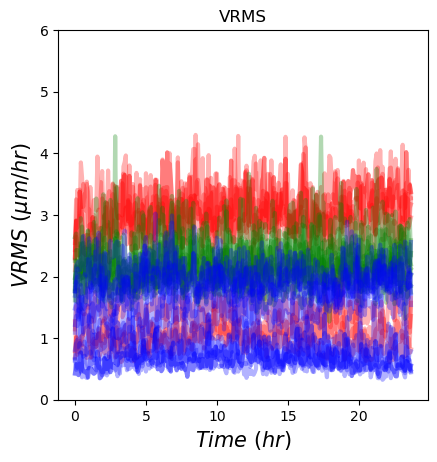

In [70]:
%matplotlib inline
df1 = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_5\_vrms3.csv")
exclude_list = [1,12,18,24]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]


plt.figure()
time = np.arange(len(df1))/12
for i,fov in enumerate(fov_lst[:]):
    if int(fov)<=11: color = "r"
    elif int(fov)>11 and int(fov)<=22: color = "g"
    else: color = "b"
    # df1[str(fov)].rolling(3).mean().plot(label=str(fov), color=color, alpha=.5, linewidth=3)
    # df1[str(fov)].plot(label=str(fov), color=color, alpha=.5, linewidth=3)
    plt.plot(time, df1[str(fov)] * .9, label=str(fov), color=color, alpha=.3, linewidth=3)
    # df1[str(fov)].plot(label=str(fov), alpha=.5, linewidth=3, color=color)
    # .plot(label=str(fov), color=color, alpha=.5)
# plt.legend()
plt.title("VRMS")
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 6)
plt.gca().set_box_aspect(1)

In [3]:
df = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_2\_vrms1.csv")

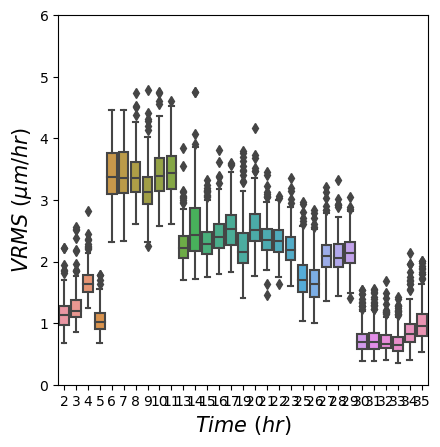

In [68]:
import seaborn as sns
df1 = pd.read_csv(r"E:\HT1080\c3_6well_5min_10x\_5\_vrms3.csv")
exclude_list = [1,12,18,24]
fov_lst = [col for col in df1.keys() if 'std' not in col and col.isdigit() and int(col) not in exclude_list]


df_selected = df1[[str(fov) for fov in fov_lst]]
# df_selected = df1[[str(fov)+"_std" for fov in fov_lst]]
df_melted = df_selected.melt(var_name='Variable', value_name='Value')
# sns.violinplot(x='Variable', y='Value', data=df_melted)
sns.boxplot(x='Variable', y='Value', data=df_melted, )#whis=(30, 60))
plt.xlabel("$Time ~(hr)$", fontsize=15)
plt.ylabel("$VRMS ~(\mu m/hr)$", fontsize=15)
plt.ylim(0, 6)
plt.gca().set_box_aspect(1)


In [28]:
def u_vel(im1,im2):
    return cv2.calcOpticalFlowFarneback(im1,im2, 
        None, 0.5, 3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)#.astype(np.float16)

frame_num = -2
# uv_vel_list = [u_vel(cv2.imread(img1)[:,900:,0],cv2.imread(img2)[:,900:,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num])]
uv_vel_list = Parallel(n_jobs=5)(delayed(u_vel)(cv2.imread(img1)[...,0],cv2.imread(img2)[...,0]) for (img1,img2) in zip(image_list[:frame_num-1],image_list[1:frame_num]))


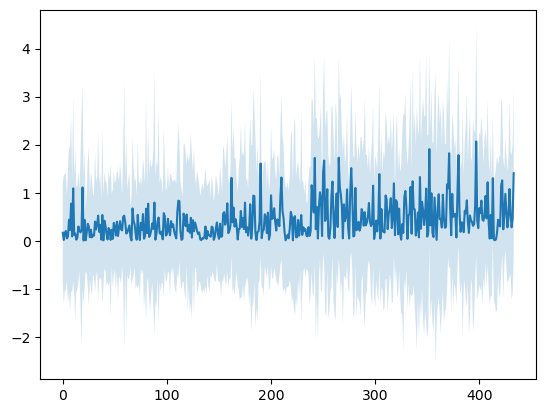

In [33]:
%matplotlib inline
vrms = [(uv[0].mean()**2 + uv[1].mean()**2)**.5 for uv in uv_vel_list]
std = [uv[0].std() for uv in uv_vel_list]
time = np.arange(len(vrms))
plt.plot(time, vrms)
plt.fill_between(time, np.array(vrms)-np.array(std), np.array(vrms)+np.array(std), alpha=.2)

In [18]:
%matplotlib qt
n = 9
img1 = cv2.imread(image_list[n])[:,:,0]
img2 = cv2.imread(image_list[n+1])[:,:,0]
flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
    winsize=10, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
flow[..., 0] = gaussian_filter(flow[..., 0], sigma=5)
flow[..., 1] = gaussian_filter(flow[..., 1], sigma=5)

step = 20
fig, ax1 = plt.subplots(1,1)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,6))
img_clahe = clahe.apply(img1)
ax1.imshow(255-img_clahe, cmap="gray")

x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)
ax1.quiver(x,y, 
        flow[::step, ::step, 0], -flow[::step, ::step, 1], #np.arctan2(flow[:,:, 1], flow[:,:,  0])[::step,::step],
        color="red", scale=250, alpha=.6, cmap='hsv', width=.005)

fig, ax2 = plt.subplots(1,1,  figsize=(4,4))
# ax2.hist(np.concatenate(v)/(i+1), 60, alpha=.3, rwidth=.9, density=True, label="v")
# ax2.hist(np.concatenate(u)/(i+1),60, alpha=.8, rwidth=.8, density=True, label="u")
ax2.hist(flow[..., 1].ravel(), 60, alpha=.3, rwidth=.9, density=True, label="v")
ax2.hist(flow[..., 0].ravel(),60, alpha=.8, rwidth=.8, density=True, label="u")
plt.legend(loc='upper right', fontsize=14)

vrms = (flow[..., 0].mean()**2 + flow[..., 1].mean()**2)**.5
print(vrms.mean())

0.7093949215617306
